In [3]:
import sys
import importlib
sys.path.insert(0, '/lustre/lrspec/users/4301/hxe-for-tda/hxetda')
import hxetda
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_recall_fscore_support
from sklearn.utils import class_weight
import numpy as np
import tqdm 

sys.path.insert(0, '/lustre/lrspec/users/4301/Milligan_ABC-SN')
import heir_loss
from plot_data import *

2026-09-01 21:51:16.788568: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-01 21:51:17.194916: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-01 21:51:20.402006: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


# Notebook runing the keras version I made, this weights the sample like how is done in their example notebook

In [4]:
# Let's import preprocess our variable star data
scaler = StandardScaler()

# I am adding some conversions here for events which are either "candidates" or have <5 objects
conversions = {'SN Ia-91T-like':'SN Iap', 
            'SN IIn-pec':'CC', 
            'TDE-H-He':'Non-SN', 
            'SN IIP':'CC', 
            'SN IIL': 'CC', 
            'SN Iax[02cx-like]': 'SN Iap',
            'SLSN-I': 'CC',
            'SLSN-II': 'CC', 
            'SN II': 'CC',
            'SN II-pec': 'CC', 
            'SN IIb': 'CC', 
            'SN IIn': 'CC', 
            'SN Ia': 'SN Ia-norm',
            'SN Ia-91T': 'SN Iap',
            'SN Ia-91bg-like': 'SN Iap',
            'SN Ia-CSM': 'SN Iap',
            'SN Ia-SC': 'SN Iap',
            'SN Ia-pec': 'SN Iap',
            'SN Iax': 'SN Iap', 
            'SN Ib': 'CC', 
            'SN Ib-pec': 'CC', 
            'SN Ib/c': 'CC', 
            'SN Ibn': 'CC',
            'SN Ic': 'CC', 
            'SN Ic-BL': 'CC', 
            'SN Ic-Ca-rich': 'CC', 
            'SN Ic-pec': 'CC', 
            'SN Icn': 'CC', 
            'TDE': 'Non-SN',
            'ILRT': 'Non-SN', 
            'LBV': 'Non-SN',
            'LRN': 'Non-SN'}


#'SN I': 'SN Ia'
def make_dataset(load=False):
    # to do - eventually, I do want to save/load a dataset...
    if not load:
        metadata, all_labels = np.loadtxt('/lustre/lrspec/users/4301/hxe-for-tda/data/training_set_dynesty.csv',usecols=(0,1), 
                                          delimiter=',', skiprows=1, dtype=str, unpack=True)
        
        # heres where to add more labels I do not want
        gind = np.where((all_labels !='Galaxy') & (all_labels !='Other') &  
                        (all_labels !='M dwarf') & (all_labels !='SN I') & 
                        (all_labels != 'AGN') &  (all_labels !='CV') &   # added by me
                        (all_labels !='Nova') &  (all_labels !='QSO') &  
                        (all_labels !='SN') &  (all_labels !='Varstar'))

        metadata = metadata[gind]
        all_labels = all_labels[gind]
        all_dat = np.zeros((len(all_labels),15))
        
        for key in conversions:
            gind = np.where(all_labels == key)
            all_labels[gind] = conversions[key]
        vertices = np.asarray(np.unique(all_labels),dtype=str)
        print(np.unique(all_labels, return_counts=True))
        vertices = np.append(vertices, ['SN Ia', 'SN'])
        vertices = np.insert(vertices, 0, 'SN-like')

        print(metadata)

        for i, md in enumerate(metadata):
            # print(md)
            one_sn_data = np.load('/lustre/lrspec/users/4301/hxe-for-tda/data/dynesty_fits/'+md+'_eqwt_dynesty.npz')
            all_dat[i] = np.mean(one_sn_data['arr_0'],axis=0)
        return(all_labels,all_dat, vertices)

labels,all_features, vertices = make_dataset()
scaler.fit(all_features)
all_features = scaler.transform(all_features)

(array(['CC', 'Non-SN', 'SN Ia-norm', 'SN Iap'], dtype='<U17'), array([1615,   60, 4173,  243]))
['ZTF23aaitimz' 'ZTF23aaikcdx' 'ZTF23aaicagr' ... 'ZTF23aacdnjz'
 'ZTF23aacjeou' 'ZTF23aaetmwj']


In [5]:
# Tell me a little about the data...
ulab, counts = np.unique(labels, return_counts=True)
for x,y in zip(ulab, counts):
    print(x,y, y/np.sum(counts))
print('Features',np.shape(all_features))

CC 1615 0.26514529633886064
Non-SN 60 0.009850599244787392
SN Ia-norm 4173 0.685109177474963
SN Iap 243 0.039894926941388936
Features (6091, 15)


['SN-like' 'CC' 'Non-SN' 'SN Ia-norm' 'SN Iap' 'SN Ia' 'SN']


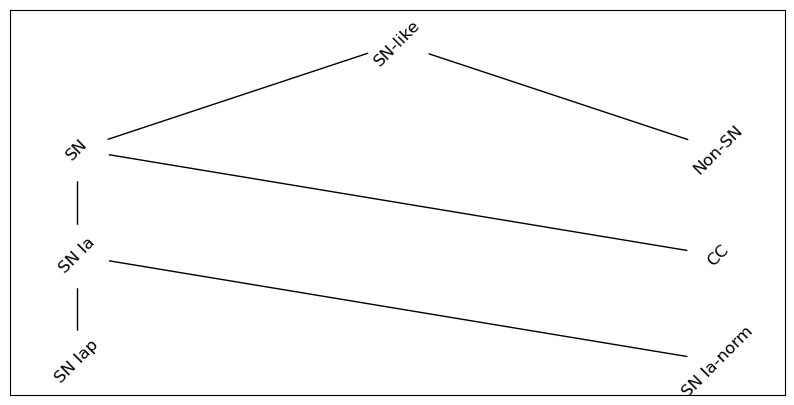

In [6]:
# Make a graph

print(vertices)
G=nx.DiGraph()

G.add_edge('SN-like', 'SN')
G.add_edge('SN-like', 'Non-SN') 

# SN Ia
G.add_edge('SN', 'SN Ia')
G.add_edge('SN Ia', 'SN Iap')
G.add_edge('SN Ia', 'SN Ia-norm')


# CC SN
G.add_edge('SN', 'CC')

importlib.reload(hxetda)
pos = hxetda.hierarchy_pos(G, 'SN-like')

fig = plt.figure(1, figsize=(10, 5))

nx.draw_networkx(G, pos=pos, nodelist=vertices, node_color='white', with_labels=False, node_size=2000, arrows=False)
text = nx.draw_networkx_labels(G, pos)
for _, t in text.items():
    t.set_rotation(45) 

plt.show()

In [7]:
vertices

array(['SN-like', 'CC', 'Non-SN', 'SN Ia-norm', 'SN Iap', 'SN Ia', 'SN'],
      dtype='<U17')

In [8]:
# Some pre-processing for the graph
paths, pathlengths, mask_list, y_dict = hxetda.calc_path_and_mask(G, vertices, 'SN-like')

In [9]:
# Some pre-processing for the hxetda class weights
class_weight_dict = hxetda.calc_class_weights(labels, vertices, paths)
class_weight_dict

weights = np.array([class_weight_dict[x] for x in labels])

In [10]:
class_weight_dict

{np.str_('CC'): array([0.94287926]),
 np.str_('Non-SN'): array([25.37916667]),
 np.str_('SN Ia-norm'): array([0.36490534]),
 np.str_('SN Iap'): array([6.26646091])}

In [11]:
# Set up for train test split...
labels_new = [y_dict[x] for x in labels]
weights = [class_weight_dict[x] for x in labels]
X_train, X_test, y_train, y_test, labels_train, labels_test, weights_train, weights_test = train_test_split(all_features, labels_new, labels, weights,
                                                                                                            test_size=0.33, random_state = 7)
# X_train = tf.convert_to_tensor(X_train, dtype=tf.float32)
# X_test = tf.convert_to_tensor(X_test, dtype=tf.float32)
# y_train = tf.convert_to_tensor(y_train, dtype=tf.float32)
# y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)

# weights_train = tf.convert_to_tensor(weights_train, dtype=tf.float32)
# weights_test = tf.convert_to_tensor(weights_test, dtype=tf.float32)

X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

weights_train = np.array(weights_train)
weights_test = np.array(weights_test)


print(np.shape(X_train))

(4080, 15)


In [20]:
from tensorflow import keras
from keras import layers

class Feedforward(keras.Model):
    def __init__(self, input_size, hidden_size, output_size):
        super(Feedforward, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        
        # Define layers
        self.fc1 = layers.Dense(hidden_size, activation='sigmoid', input_shape=(input_size,))
        self.fc2 = layers.Dense(hidden_size, activation='sigmoid')
        self.fc3 = layers.Dense(output_size)
        
    def call(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        return x

# Running using sample weights

4080


100%|██████████| 1000/1000 [17:55<00:00,  1.08s/it]


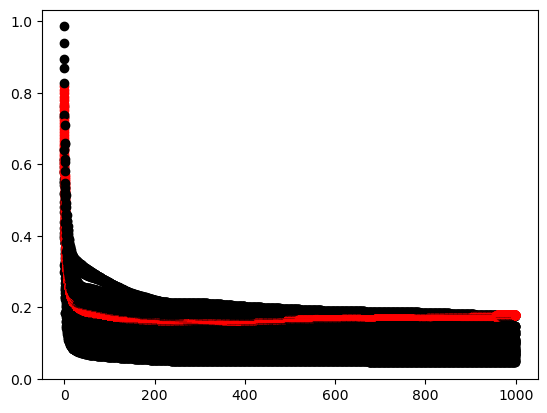

In [24]:
import tensorflow as tf


# Create and compile the model
model = Feedforward(np.shape(X_test[0])[0], 15, len(vertices))

# Use AdamW optimizer in Keras (equivalent to torch.optim.AdamW)
optimizer = keras.optimizers.AdamW(learning_rate=0.001)

# my loss function 
loss_fn = heir_loss.WeightedHierchicalLoss_hxetda(mask_list, pathlengths, alpha=0.5)

# Compile the model - we'll use a custom training loop since you have custom loss
# Note: We won't use model.compile() since we need custom training loop

epochs = 1000
batch_size = 128
n_batches = len(X_train) // batch_size + (1 if len(X_train) % batch_size != 0 else 0)

print(len(X_train))

# Lists to store loss values for plotting
loss_history = []
loss2_history = []

run = True

if run: 
    for epoch in tqdm.tqdm(range(epochs)):
        # if epoch % 10 == 1:
            # if loss_history and loss2_history:
                # print(epoch, np.log10(loss_history[-1]), np.log10(loss2_history[-1]))
        
        # # Shuffle data at the beginning of each epoch (optional but recommended)
        # indices = np.random.permutation(len(X_train))
        # X_train_shuffled = X_train[indices]
        # y_train_shuffled = y_train[indices]
        # weights_train_shuffled = weights_train[indices]
        
        for i in range(n_batches):
            # Local batches and labels
            local_X = X_train[i*batch_size:(i+1)*batch_size]
            local_y = y_train[i*batch_size:(i+1)*batch_size]
            local_weights = weights_train[i*batch_size:(i+1)*batch_size]
            
            # # Convert to tensors if needed (Keras works with numpy arrays too)
            # local_X = tf.convert_to_tensor(local_X, dtype=tf.float32)
            # local_y = tf.convert_to_tensor(local_y, dtype=tf.float32)
            # local_weights = tf.convert_to_tensor(local_weights, dtype=tf.float32)
            
            # Forward pass using GradientTape for automatic differentiation
            with tf.GradientTape() as tape:
                y_pred = model(local_X, training=True)
                # Compute Loss - your custom loss function
                loss = loss_fn(local_y, y_pred, sample_weight=local_weights)
            
            # Get gradients
            gradients = tape.gradient(loss, model.trainable_variables)
            # Apply gradients
            optimizer.apply_gradients(zip(gradients, model.trainable_variables))
            
            # Store loss
            loss_history.append(loss.numpy())
            
            # Plot training loss
            plt.plot(epoch, loss.numpy(), 'ko')
            
            # Compute test loss
            ypred2 = model(X_test, training=False)
            loss2 = loss_fn(y_test, ypred2, weights_test)
            loss2_history.append(loss2.numpy())
            
            # Plot test loss
            plt.plot(epoch, loss2.numpy(), 'ro')
    
    plt.show()

In [14]:
!pwd

/lustre/lrspec/users/4301/hxe-for-tda


In [25]:
model_name = "forward_feed_truncate"

if run:
    model.save(f"{model_name}.keras")

else:
    model = keras.models.load_model(f"{model_name}.keras", compile=False)

### Note weird stripes in loss I believe are due to not shuffling data, in order to show the same results I didn't change this for this proof of concept


In [26]:
# model.eval()
y_pred = model(X_test)
y_pred = torch.Tensor(np.array(y_pred))

547


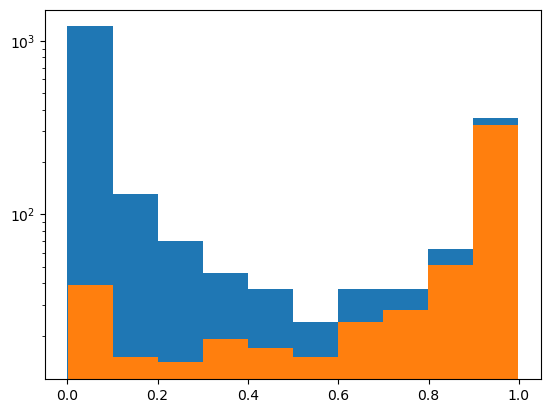

In [27]:
#Play around with different classes
specific_class = 'CC'
single_class_prob = hxetda.get_prob(y_pred,specific_class, paths, vertices, mask_list).detach().numpy()
plt.hist(single_class_prob)
plt.yscale('log')

gind = np.where(single_class_prob>0.1)
# print(labels_test[gind])
gind2 = np.where(labels_test == specific_class)
plt.hist(single_class_prob[gind2])
print(len(gind2[0]))


# 2-way task

2011
['SN' 'Non-SN']
SN Ia-norm [9.99522090e-01 4.77906025e-04]
(0.8440029985007496, 0.6121456500488759, 0.6673405995552043, None)
(0.9865738438587768, 0.9865738438587768, 0.9865738438587768, None)


/tmp/ipykernel_64123/1297617116.py:19: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  gind = np.where(np.in1d(twoclass_labels_test,leaves))[0]


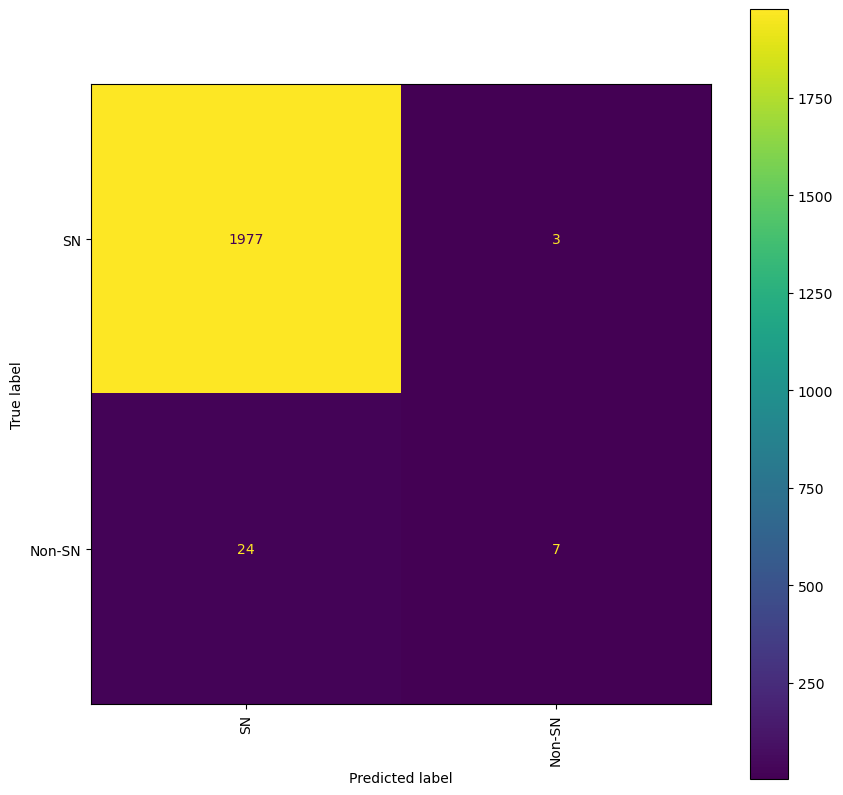

In [33]:
# 2-way task...
# Get my leaves...
importlib.reload(hxetda)

leaves = np.asarray(['SN', 'Non-SN'], dtype=str)
probs_list = np.zeros((len(y_pred), len(leaves)))
for i,leaf in enumerate(leaves):
    probs_list[:,i] = hxetda.get_prob(y_pred,leaf, paths, vertices, mask_list).detach().numpy()

my_predicted_types = leaves[np.argmax(probs_list,axis=1)]

twoclass_labels_test = np.copy(labels_test)

for i,s in enumerate(twoclass_labels_test):
    is_Ibc = hxetda.is_parent(s, 'SN', vertices, paths)
    if is_Ibc:
        twoclass_labels_test[i] = 'SN'

gind = np.where(np.in1d(twoclass_labels_test,leaves))[0]
cm = confusion_matrix(twoclass_labels_test[gind], my_predicted_types[gind], labels=leaves)
disp = ConfusionMatrixDisplay(cm, display_labels=leaves)
fig, ax = plt.subplots(figsize=(10,10))
disp.plot(xticks_rotation='vertical', ax=ax)
print(len(gind))
print(leaves)
print(labels_test[gind][9], probs_list[gind][9])

print(precision_recall_fscore_support(twoclass_labels_test[gind], my_predicted_types[gind],average='macro'))
print(precision_recall_fscore_support(twoclass_labels_test[gind], my_predicted_types[gind],average='micro'))

/tmp/ipykernel_64123/3577454382.py:15: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  gind = np.where(np.in1d(twoclass_labels_test,leaves))[0]


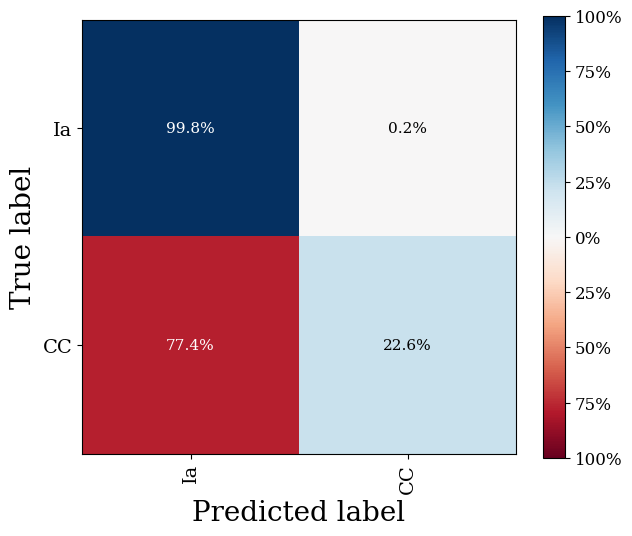

In [42]:
leaves = np.asarray(['SN', 'Non-SN'], dtype=str)
probs_list = np.zeros((len(y_pred), len(leaves)))
for i,leaf in enumerate(leaves):
    probs_list[:,i] = hxetda.get_prob(y_pred,leaf, paths, vertices, mask_list).detach().numpy()

my_predicted_types = leaves[np.argmax(probs_list,axis=1)]

twoclass_labels_test = np.copy(labels_test)

for i,s in enumerate(twoclass_labels_test):
    is_Ibc = hxetda.is_parent(s, 'SN', vertices, paths)
    if is_Ibc:
        twoclass_labels_test[i] = 'SN'

gind = np.where(np.in1d(twoclass_labels_test,leaves))[0]
cm = confusion_matrix(twoclass_labels_test[gind], my_predicted_types[gind], labels=leaves)
plot = plot_cm(cm, leaves_wanted, figsize = (7,7),
        title = "")

In [63]:
np.unique(my_predicted_types)

array([0, 1])

In [67]:
leaves = np.asarray(['SN', 'Non-SN'], dtype=str)
probs_list = np.zeros((len(y_pred), len(leaves)))
for i,leaf in enumerate(leaves):
    probs_list[:,i] = hxetda.get_prob(y_pred,leaf, paths, vertices, mask_list).detach().numpy()

my_predicted_types = np.argmax(probs_list,axis=1)


# get true matrix
y_matrix_true = np.zeros((len(y_pred), len(leaves_wanted)))

for i,leaf in enumerate(leaves):
    col = np.where(vertices == leaf)[0][0]
    y_matrix_true[:,i] = y_test[:,col]

y_true = np.argmax(y_matrix_true, axis=1)

# cm = confusion_matrix(y_true, my_predicted_types)
# plot = plot_cm(cm, leaves, figsize = (7,7),
#         title = "")

# second method as a check

In [44]:
my_predicted_types

array(['SN', 'SN', 'SN', ..., 'SN', 'SN', 'SN'], dtype='<U6')

In [72]:
vertices

array(['SN-like', 'CC', 'Non-SN', 'SN Ia-norm', 'SN Iap', 'SN Ia', 'SN'],
      dtype='<U17')

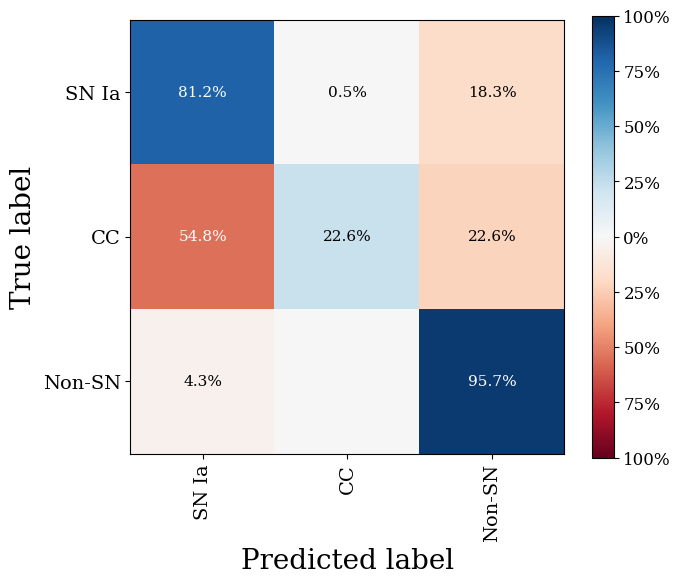

In [82]:
leaves = np.asarray(['SN Ia', 'CC', 'Non-SN'], dtype=str)
probs_list = np.zeros((len(y_pred), len(leaves)))
for i,leaf in enumerate(leaves):
    probs_list[:,i] = hxetda.get_prob(y_pred,leaf, paths, vertices, mask_list).detach().numpy()

my_predicted_types = leaves[np.argmax(probs_list,axis=1)]

true_labels = np.copy(labels_test)

for i,s in enumerate(true_labels):
    for j,leaf in enumerate(leaves):
        if hxetda.is_parent(s, leaf, vertices, paths):
            true_labels[i] = leaf

cm = confusion_matrix(true_labels, my_predicted_types)
plot = plot_cm(cm, leaves, figsize = (7,7),
        title = "")

### red/negative means this model did worse than theres, this seems all in line within reason to me

In [83]:
from sklearn.metrics import classification_report

cr = (classification_report(
    fiveleaf_labels_test[gind], my_predicted_types[gind], 
    target_names=leaves))

print(cr) 

NameError: name 'fiveleaf_labels_test' is not defined

# stopping here as below they use Cross Entropy instead of their custom loss

In [60]:
# # Now for the same training/test set...train a baseline
# # Train!

# gind = np.where(np.in1d(fiveleaf_labels_test,leaves))[0]
# baseline_Xtest = X_test[gind]
# baseline_ytest = y_test[gind]
# baseline_labels_test = fiveleaf_labels_test[gind]

# print(len(gind))

# gind = np.where(np.in1d(labels_train,leaves))[0]
# baseline_Xtrain = X_train[gind]
# baseline_ytrain = y_train[gind]
# baseline_labels_train = labels_train[gind]

# # Now only keep relevant columns...

# new_baseline_ytest = np.zeros((len(baseline_ytest), len(leaves)))
# new_baseline_ytrain = np.zeros((len(baseline_ytrain), len(leaves)))

# for i,leaf in enumerate(leaves):
#     j = np.where(leaf == vertices)[0][0]
#     new_baseline_ytrain[:,i] = baseline_ytrain[:,j]
#     new_baseline_ytest[:,i] = baseline_ytest[:,j]

# baseline_ytrain = torch.tensor(new_baseline_ytrain)
# baseline_ytest = torch.tensor(baseline_ytest)

# model_baseline = hxetda.Feedforward(np.shape(X_test[0])[0],15, len(leaves))
# optimizer = torch.optim.AdamW(model_baseline.parameters(), lr = 0.01)
# model_baseline.train()
# epoch = 2000
# n_batches = 1024


# #class_weights=class_weight.compute_class_weight('balanced',classes=np.unique(labels_test),y=my_predicted_types)

# myloss = torch.nn.CrossEntropyLoss()

# for epoch in range(epoch):
# 	for i in range(int(len(baseline_Xtrain)/n_batches)+1):
# 		# Local batches and labels
# 		local_X, local_y = baseline_Xtrain[i*n_batches:(i+1)*n_batches,], baseline_ytrain[i*n_batches:(i+1)*n_batches,]
# 		optimizer.zero_grad()
# 		# Forward pass
# 		y_pred_baseline = model_baseline(local_X)
# 		# Compute Loss
# 		loss = myloss(y_pred_baseline,local_y)
# 		# Backward pass
# 		loss.backward()
# 		optimizer.step()
# 		plt.plot(epoch,loss.detach().numpy(),'ko')
# 	#scheduler.step()
# plt.show()

In [ ]:
# model_baseline.eval()
# y_pred_baseline = model_baseline(baseline_Xtest).detach().numpy()
# predicted_baseline_types = leaves[np.argmax(y_pred_baseline,axis=1)]
# cm = confusion_matrix(baseline_labels_test, predicted_baseline_types, labels=leaves)
# disp = ConfusionMatrixDisplay(cm, display_labels=leaves)
# fig, ax = plt.subplots(figsize=(10,10))
# disp.plot(xticks_rotation='vertical', ax=ax)

# print(precision_recall_fscore_support(baseline_labels_test, predicted_baseline_types,average='macro'))
# print(precision_recall_fscore_support(baseline_labels_test, predicted_baseline_types,average='micro'))

## Sibling task

In [61]:
# importlib.reload(hxetda)

# siblings = np.asarray(['StellarTransient', 'SN-like'])
# probs_list = np.zeros((len(y_pred), len(siblings)))
# for i,sib in enumerate(siblings):
#     probs_list[:,i] = hxetda.get_prob(y_pred,sib, paths, vertices, mask_list).detach().numpy()

# my_predicted_types = siblings[np.argmax(probs_list,axis=1)]

# sibling_labels_test = np.copy(labels_test)
# for i,s in enumerate(sibling_labels_test):
#     is_StellarTransient = hxetda.is_parent(s, 'StellarTransient', vertices, paths)

#     if is_StellarTransient:
#         sibling_labels_test[i] = 'StellarTransient'
#     else:
#         sibling_labels_test[i] = 'SN-like'


# cm = confusion_matrix(sibling_labels_test, my_predicted_types, labels=siblings)
# disp = ConfusionMatrixDisplay(cm, display_labels=siblings)
# fig, ax = plt.subplots(figsize=(10,10))
# disp.plot(xticks_rotation='vertical', ax=ax)

# print(precision_recall_fscore_support(sibling_labels_test, my_predicted_types,average='macro'))
# print(precision_recall_fscore_support(sibling_labels_test, my_predicted_types,average='micro'))

In [ ]:
# # And now baseline...
# # Now for the same training/test set...train a baseline
# # Train!

# siblings = np.asarray(['StellarTransient', 'SN-like'])

# baseline_ytest = np.zeros((len(y_test), len(siblings)))
# sibling_labels_test = np.copy(labels_test)
# for i,s in enumerate(sibling_labels_test):
#     is_StellarTransient = hxetda.is_parent(s, 'StellarTransient', vertices, paths)

#     if is_StellarTransient:
#         sibling_labels_test[i] = 'StellarTransient'
#         baseline_ytest[i,0] = 1

#     else:
#         sibling_labels_test[i] = 'SN-like'
#         baseline_ytest[i,1] = 1



# baseline_ytrain = np.zeros((len(y_train), len(siblings)))
# sibling_labels_train = np.copy(labels_train)
# for i,s in enumerate(sibling_labels_train):
#     is_StellarTransient = hxetda.is_parent(s, 'StellarTransient', vertices, paths)

#     if is_StellarTransient:
#         sibling_labels_train[i] = 'StellarTransient'
#         baseline_ytrain[i,0] = 1

#     else:
#         sibling_labels_train[i] = 'SN-like'
#         baseline_ytrain[i,1] = 1


# baseline_ytrain = torch.tensor(baseline_ytrain)
# baseline_ytest = torch.tensor(baseline_ytest)

# model_baseline = hxetda.Feedforward(np.shape(X_test[0])[0],15, len(siblings))
# optimizer = torch.optim.AdamW(model_baseline.parameters(), lr = 0.05)
# model_baseline.train()
# epoch = 1000
# n_batches = 1024

# baseline_Xtrain = torch.tensor(np.copy(X_train))
# baseline_Xtest = torch.tensor(np.copy(X_test))

# myloss = torch.nn.CrossEntropyLoss()

# for epoch in range(epoch):
# 	for i in range(int(len(baseline_Xtrain)/n_batches)+1):
# 		# Local batches and labels
# 		local_X, local_y = baseline_Xtrain[i*n_batches:(i+1)*n_batches,], baseline_ytrain[i*n_batches:(i+1)*n_batches,]
# 		optimizer.zero_grad()
# 		# Forward pass
# 		y_pred_baseline = model_baseline(local_X)
# 		# Compute Loss
# 		loss = myloss(y_pred_baseline,local_y)
# 		# Backward pass
# 		loss.backward()
# 		optimizer.step()
# 		plt.plot(epoch,loss.detach().numpy(),'ko')
# plt.show()

In [ ]:
# model_baseline.eval()
# y_pred_baseline = model_baseline(baseline_Xtest).detach().numpy()
# predicted_baseline_types = siblings[np.argmax(y_pred_baseline,axis=1)]
# cm = confusion_matrix(sibling_labels_test, predicted_baseline_types, labels=siblings)
# disp = ConfusionMatrixDisplay(cm, display_labels=siblings)
# fig, ax = plt.subplots(figsize=(10,10))
# disp.plot(xticks_rotation='vertical', ax=ax)

# print(precision_recall_fscore_support(sibling_labels_test, predicted_baseline_types,average='macro'))
# print(precision_recall_fscore_support(sibling_labels_test, predicted_baseline_types,average='micro'))